# 1.0 Load Prepared Dataset

- Load the finalized 2025 order-level dataset used in prior workbooks.
- Confirm dataset structure, column availability, and readiness for behavioral modeling.
- Establish this dataset as the foundation for order-level clustering and segmentation.
- Validate presence of key engineered fields:
  - order_total
  - order_hour
  - order_dow
  - order_segment

## 1.1 Import Libraries

- Import required libraries for data loading and analysis.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

## 1.2 Load Dataset

- Load cleaned order-level dataset from data directory.
- This dataset should already include engineered features from prior workbooks.

In [44]:
orders = pd.read_csv('../data/cleaned/orders_2025_full.csv')

display(orders.head())
print('Shape:', orders.shape)

,Order Date,Order ID,Order Type,Tax Amount,Tip,Discount,Order Total,Payments Total,Tender
0,2025-03-31 22:54:00-07:00,QQBMWE3NMZQ0Y,Pick Up,2.09,0.00,0.0,25.99,25.99,Cash
1,2025-03-31 22:35:00-07:00,TH041BMRDC2Y6,Delivery,0.00,0.00,0.0,25.13,0.00,NaN
2,2025-03-31 22:33:00-07:00,06KJV691ZMV48,Pick Up,1.44,3.29,0.0,17.90,17.90,Debit Card
3,2025-03-31 22:24:00-07:00,ASKA2CPN7GT2A,Pick Up,3.27,0.00,0.0,40.69,40.69,Cash
4,2025-03-31 22:23:00-07:00,GK5Z5D128NA1M,Pick Up,1.61,0.92,0.0,20.05,20.05,Credit Card


Shape: (50487, 9)


## 1.3 Validate Dataset Structure

- Confirm required columns exist for behavioral modeling:
  - order_total
  - order_hour
  - order_dow
  - order_segment
- Inspect column list to verify readiness for next steps.

In [45]:
print(orders.columns.tolist())

['Order Date', 'Order ID', 'Order Type', 'Tax Amount', 'Tip', 'Discount', 'Order Total', 'Payments Total', 'Tender']


# 2.0 Feature Preparation

- Convert the order date field to proper datetime format.
- Recreate core time-based features required for behavioral analysis.
- Create a clean working dataset for Workbook 10.
- Ensure all downstream segmentation is based on reproducible feature engineering.

## 2.1 Select Required Columns

- Keep only the fields required for behavioral clustering and segmentation.
- Standardize column names for consistency across the notebook.

In [46]:
orders_base = orders[[
    'Order ID',
    'Order Date',
    'Order Total',
    'Discount'
]].copy()

orders_base.columns = [
    'order_id',
    'order_datetime',
    'order_total',
    'discount_amount'
]

display(orders_base.head())
print('Shape:', orders_base.shape)

,order_id,order_datetime,order_total,discount_amount
0,QQBMWE3NMZQ0Y,2025-03-31 22:54:00-07:00,25.99,0.0
1,TH041BMRDC2Y6,2025-03-31 22:35:00-07:00,25.13,0.0
2,06KJV691ZMV48,2025-03-31 22:33:00-07:00,17.90,0.0
3,ASKA2CPN7GT2A,2025-03-31 22:24:00-07:00,40.69,0.0
4,GK5Z5D128NA1M,2025-03-31 22:23:00-07:00,20.05,0.0


Shape: (50487, 4)


## 2.2 Convert Order Datetime (UTC → PST)

- Convert the order_datetime field to proper datetime format.
- Standardize timezone to UTC, then convert to Pacific Time (PST/PDT).
- Ensure time-based analysis reflects actual store operating hours.

In [47]:
orders_base['order_datetime'] = pd.to_datetime(orders_base['order_datetime'], utc=True)

# Convert to Pacific Time
orders_base['order_datetime'] = orders_base['order_datetime'].dt.tz_convert('America/Los_Angeles')

display(orders_base[['order_datetime']].head())

,order_datetime
0,2025-03-31 22:54:00-07:00
1,2025-03-31 22:35:00-07:00
2,2025-03-31 22:33:00-07:00
3,2025-03-31 22:24:00-07:00
4,2025-03-31 22:23:00-07:00


## 2.3 Create Time-Based Features

- Engineer core behavioral fields from order_datetime:
  - order_hour (local time)
  - order_dow
  - order_date
  - is_weekend
- Ensure all features reflect local business time for accurate behavioral analysis.

In [48]:
orders_base['order_hour'] = orders_base['order_datetime'].dt.hour
orders_base['order_dow'] = orders_base['order_datetime'].dt.dayofweek
orders_base['order_date'] = orders_base['order_datetime'].dt.date
orders_base['is_weekend'] = orders_base['order_dow'].isin([5, 6])

display(
    orders_base[
        ['order_datetime', 'order_hour', 'order_dow', 'order_date', 'is_weekend']
    ].head()
)

,order_datetime,order_hour,order_dow,order_date,is_weekend
0,2025-03-31 22:54:00-07:00,22,0,2025-03-31,False
1,2025-03-31 22:35:00-07:00,22,0,2025-03-31,False
2,2025-03-31 22:33:00-07:00,22,0,2025-03-31,False
3,2025-03-31 22:24:00-07:00,22,0,2025-03-31,False
4,2025-03-31 22:23:00-07:00,22,0,2025-03-31,False


# 3.0 Behavioral Segmentation Framework

- Define order-level behavioral segments based on order value.
- Create a structured segmentation system to approximate customer behavior without customer identifiers.
- Use percentile-based thresholds to categorize orders into value tiers:
  - Low
  - Mid
  - High
  - Very High
- Establish segmentation as the foundation for behavioral clustering and revenue analysis.

## 3.1 Compute Order Value Percentiles

- Calculate percentile thresholds for order_total.
- Use these thresholds to define segment boundaries.

In [49]:
p25 = orders_base['order_total'].quantile(0.25)
p50 = orders_base['order_total'].quantile(0.50)
p75 = orders_base['order_total'].quantile(0.75)

print('25th percentile:', round(p25, 2))
print('50th percentile:', round(p50, 2))
print('75th percentile:', round(p75, 2))

25th percentile: 16.95
50th percentile: 29.17
75th percentile: 39.53


## 3.2 Assign Order Segments

- Segment each order into value tiers based on percentile thresholds.
- Create categorical variable order_segment.

In [50]:
def assign_segment(x):
    if x <= p25:
        return 'Low'
    elif x <= p50:
        return 'Mid'
    elif x <= p75:
        return 'High'
    else:
        return 'Very High'

orders_base['order_segment'] = orders_base['order_total'].apply(assign_segment)

display(orders_base[['order_total', 'order_segment']].head())

,order_total,order_segment
0,25.99,Mid
1,25.13,Mid
2,17.90,Mid
3,40.69,Very High
4,20.05,Mid


## 3.3 Validate Segment Distribution

- Confirm distribution of orders across segments.
- Ensure segmentation is balanced and reasonable.

In [51]:
segment_dist = orders_base['order_segment'].value_counts(normalize=True).round(3)

print(segment_dist)

order_segment
High         0.25
Low          0.25
Mid          0.25
Very High    0.25
Name: proportion, dtype: float64


## 3.4 Segment Summary Metrics

- Analyze average order value and total revenue by segment.
- Validate that higher segments correspond to higher revenue contribution.

In [52]:
segment_summary = (
    orders_base
    .groupby('order_segment')
    .agg(
        order_count=('order_id', 'count'),
        avg_order_value=('order_total', 'mean'),
        total_revenue=('order_total', 'sum')
    )
    .reset_index()
)

display(segment_summary)

,order_segment,order_count,avg_order_value,total_revenue
0,High,12636,34.026530,429959.23
1,Low,12626,6.733722,85019.98
2,Mid,12618,23.551979,297178.87
3,Very High,12607,58.507100,737599.01


# 4.0 Behavioral Analysis by Time and Segment

- Analyze how order value segments behave across time dimensions.
- Evaluate how revenue and order volume vary by:
  - Hour of day
  - Day of week
- Identify high-value behavioral patterns that drive revenue.
- Establish foundation for time-based targeting and optimization strategies.

## 4.1 Order Volume by Hour and Segment

- Analyze distribution of order counts across hours for each segment.
- Identify peak hours and segment dominance by time of day.

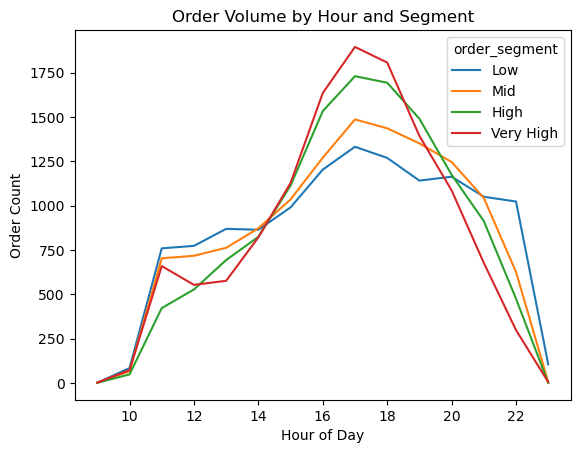

In [53]:
segment_hour = (
    orders_base
    .groupby(['order_segment', 'order_hour'])
    .size()
    .reset_index(name='order_count')
)

pivot_hour = (
    segment_hour
    .pivot(index='order_hour', columns='order_segment', values='order_count')
    .fillna(0)
)

order = ['Low', 'Mid', 'High', 'Very High']
pivot_hour = pivot_hour[order]

pivot_hour.plot()

plt.title('Order Volume by Hour and Segment')
plt.xlabel('Hour of Day')
plt.ylabel('Order Count')

plt.show()

## 4.2 Revenue by Hour and Segment

- Analyze how revenue contribution varies by hour across segments.
- Identify peak revenue windows and dominant segments.

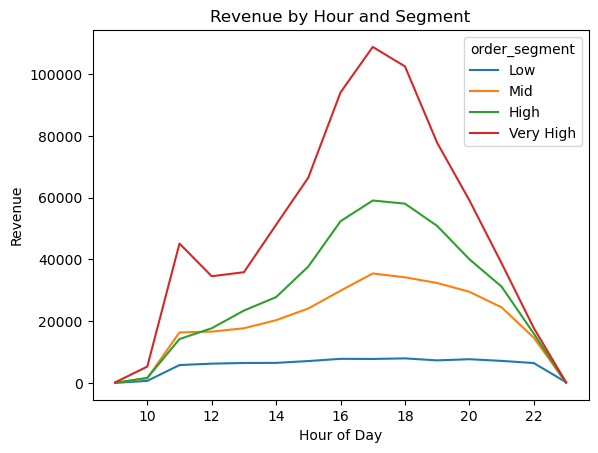

In [54]:
segment_hour_rev = (
    orders_base
    .groupby(['order_segment', 'order_hour'])
    .agg(total_revenue=('order_total', 'sum'))
    .reset_index()
)

pivot_hour_rev = (
    segment_hour_rev
    .pivot(index='order_hour', columns='order_segment', values='total_revenue')
    .fillna(0)
)

pivot_hour_rev = pivot_hour_rev[order]

pivot_hour_rev.plot()

plt.title('Revenue by Hour and Segment')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue')

plt.show()

## 4.3 Order Volume by Day of Week and Segment

- Analyze weekly patterns of order volume across segments.
- Identify high-demand days and segment contribution.

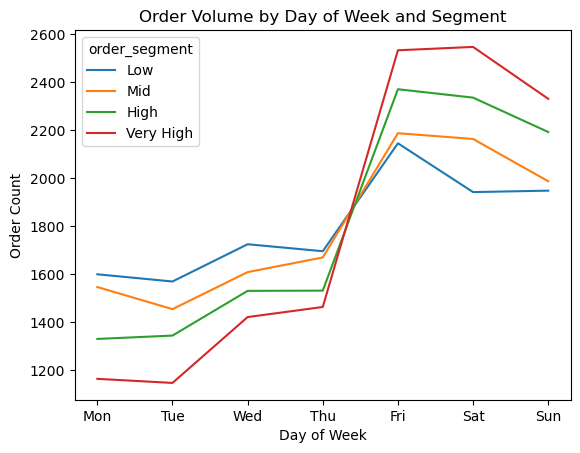

In [55]:
segment_dow = (
    orders_base
    .groupby(['order_segment', 'order_dow'])
    .size()
    .reset_index(name='order_count')
)

pivot_dow = (
    segment_dow
    .pivot(index='order_dow', columns='order_segment', values='order_count')
    .fillna(0)
)

pivot_dow = pivot_dow[order]

pivot_dow.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pivot_dow.plot()

plt.title('Order Volume by Day of Week and Segment')
plt.xlabel('Day of Week')
plt.ylabel('Order Count')

plt.show()

## 4.4 Revenue by Day of Week and Segment

- Analyze how revenue varies across the week by segment.
- Identify high-value days and segment-level contribution.

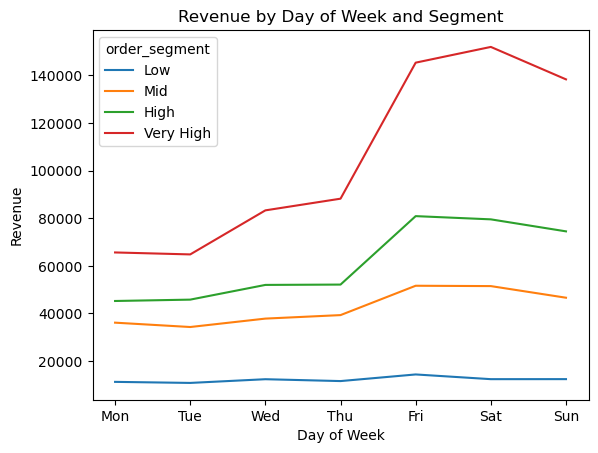

In [56]:
segment_dow_rev = (
    orders_base
    .groupby(['order_segment', 'order_dow'])
    .agg(total_revenue=('order_total', 'sum'))
    .reset_index()
)

pivot_dow_rev = (
    segment_dow_rev
    .pivot(index='order_dow', columns='order_segment', values='total_revenue')
    .fillna(0)
)

pivot_dow_rev = pivot_dow_rev[order]

pivot_dow_rev.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

pivot_dow_rev.plot()

plt.title('Revenue by Day of Week and Segment')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')

plt.show()

# 5.0 Behavioral Clustering & Segment Profiling

- Combine time-based features with order value segments to build behavioral profiles.
- Identify distinct behavioral groups based on when and how customers order.
- Translate order-level patterns into actionable “pseudo-customer” segments.
- Establish foundation for targeted promotions and revenue optimization.

## 5.1 Peak Hour Identification by Segment

- Identify peak ordering hour for each order segment.
- Determine when each segment is most active.

In [57]:
peak_hour = (
    orders_base
    .groupby(['order_segment', 'order_hour'])
    .size()
    .reset_index(name='order_count')
    .sort_values(['order_segment', 'order_count'], ascending=[True, False])
    .groupby('order_segment')
    .head(1)
)

display(peak_hour)

,order_segment,order_hour,order_count
8,High,17,1730
22,Low,17,1332
37,Mid,17,1486
52,Very High,17,1895


## 5.2 Peak Day Identification by Segment

- Identify highest order volume day of week for each segment.
- Understand weekly behavioral differences across segments.

In [58]:
peak_day = (
    orders_base
    .groupby(['order_segment', 'order_dow'])
    .size()
    .reset_index(name='order_count')
    .sort_values(['order_segment', 'order_count'], ascending=[True, False])
    .groupby('order_segment')
    .head(1)
)

day_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
peak_day['day_name'] = peak_day['order_dow'].map(day_map)

display(peak_day)

,order_segment,order_dow,order_count,day_name
4,High,4,2370,Fri
11,Low,4,2145,Fri
18,Mid,4,2187,Fri
26,Very High,5,2546,Sat


## 5.3 Weekend vs Weekday Behavior

- Compare order behavior between weekdays and weekends.
- Identify which segments drive weekend demand.

In [59]:
weekend_behavior = (
    orders_base
    .groupby(['order_segment', 'is_weekend'])
    .agg(
        order_count=('order_id', 'count'),
        total_revenue=('order_total', 'sum')
    )
    .reset_index()
)

display(weekend_behavior)

,order_segment,is_weekend,order_count,total_revenue
0,High,False,8109,275963.44
1,High,True,4527,153995.79
2,Low,False,8736,60272.76
3,Low,True,3890,24747.22
4,Mid,False,8468,199112.01
5,Mid,True,4150,98066.86
6,Very High,False,7731,447274.81
7,Very High,True,4876,290324.20


## 5.4 Behavioral Profile Summary

- Aggregate key metrics to define behavioral profiles for each segment.
- Summarize when, how often, and how much each segment contributes.

In [60]:
behavior_profile = (
    orders_base
    .groupby('order_segment')
    .agg(
        total_orders=('order_id', 'count'),
        avg_order_value=('order_total', 'mean'),
        total_revenue=('order_total', 'sum'),
        avg_hour=('order_hour', 'mean'),
        weekend_share=('is_weekend', 'mean')
    )
    .reset_index()
)

display(behavior_profile)

,order_segment,total_orders,avg_order_value,total_revenue,avg_hour,weekend_share
0,High,12636,34.026530,429959.23,16.976891,0.358262
1,Low,12626,6.733722,85019.98,16.898543,0.308094
2,Mid,12618,23.551979,297178.87,16.835552,0.328895
3,Very High,12607,58.507100,737599.01,16.697152,0.386769


## 5.5 Segment Ranking by Revenue Contribution

- Rank segments based on total revenue contribution.
- Identify which behavioral groups drive the majority of revenue.

In [61]:
behavior_profile['revenue_rank'] = behavior_profile['total_revenue'].rank(ascending=False)

behavior_profile = behavior_profile.sort_values('revenue_rank')

display(behavior_profile)

,order_segment,total_orders,avg_order_value,total_revenue,avg_hour,weekend_share,revenue_rank
3,Very High,12607,58.507100,737599.01,16.697152,0.386769,1.0
0,High,12636,34.026530,429959.23,16.976891,0.358262,2.0
2,Mid,12618,23.551979,297178.87,16.835552,0.328895,3.0
1,Low,12626,6.733722,85019.98,16.898543,0.308094,4.0


## 5.6 Behavioral Insights (Preparation for Strategy Layer)

- Prepare structured dataset for strategic recommendations.
- This dataset will feed into business decision-making in the next section.

In [62]:
behavior_profile = behavior_profile.sort_values('total_revenue', ascending=False)

display(behavior_profile)

,order_segment,total_orders,avg_order_value,total_revenue,avg_hour,weekend_share,revenue_rank
3,Very High,12607,58.507100,737599.01,16.697152,0.386769,1.0
0,High,12636,34.026530,429959.23,16.976891,0.358262,2.0
2,Mid,12618,23.551979,297178.87,16.835552,0.328895,3.0
1,Low,12626,6.733722,85019.98,16.898543,0.308094,4.0


# 6.0 Revenue Contribution & Behavioral Impact

- Quantify how each behavioral segment contributes to total revenue.
- Identify disproportionate revenue drivers across segments.
- Translate behavioral patterns into measurable business impact.
- Establish clear prioritization for growth strategies.

## 6.1 Revenue Share by Segment

- Calculate percentage contribution of each segment to total revenue.
- Highlight which segments disproportionately drive revenue.

In [63]:
behavior_profile['revenue_share'] = (
    behavior_profile['total_revenue'] / behavior_profile['total_revenue'].sum()
)

display(behavior_profile[['order_segment', 'total_revenue', 'revenue_share']])

,order_segment,total_revenue,revenue_share
3,Very High,737599.01,0.475945
0,High,429959.23,0.277437
2,Mid,297178.87,0.191758
1,Low,85019.98,0.054860


## 6.2 Order Share vs Revenue Share

- Compare order volume share vs revenue share across segments.
- Identify segments that overperform or underperform relative to volume.

In [64]:
behavior_profile['order_share'] = (
    behavior_profile['total_orders'] / behavior_profile['total_orders'].sum()
)

behavior_profile['revenue_to_order_ratio'] = (
    behavior_profile['revenue_share'] / behavior_profile['order_share']
)

display(
    behavior_profile[
        ['order_segment', 'order_share', 'revenue_share', 'revenue_to_order_ratio']
    ]
)

,order_segment,order_share,revenue_share,revenue_to_order_ratio
3,Very High,0.249708,0.475945,1.906007
0,High,0.250282,0.277437,1.108495
2,Mid,0.249926,0.191758,0.767261
1,Low,0.250084,0.054860,0.219367


## 6.3 High-Impact Segment Identification

- Identify segments with highest revenue efficiency.
- Focus on segments with high revenue-to-order ratios.

In [65]:
high_impact_segments = behavior_profile.sort_values(
    'revenue_to_order_ratio', ascending=False
)

display(high_impact_segments)

,order_segment,total_orders,avg_order_value,total_revenue,avg_hour,weekend_share,revenue_rank,revenue_share,order_share,revenue_to_order_ratio
3,Very High,12607,58.507100,737599.01,16.697152,0.386769,1.0,0.475945,0.249708,1.906007
0,High,12636,34.026530,429959.23,16.976891,0.358262,2.0,0.277437,0.250282,1.108495
2,Mid,12618,23.551979,297178.87,16.835552,0.328895,3.0,0.191758,0.249926,0.767261
1,Low,12626,6.733722,85019.98,16.898543,0.308094,4.0,0.054860,0.250084,0.219367


## 6.4 Revenue Concentration by Segment

- Measure cumulative revenue contribution across segments.
- Evaluate how concentrated revenue is across behavioral groups.

In [66]:
behavior_profile_sorted = behavior_profile.sort_values(
    'total_revenue', ascending=False
).reset_index(drop=True)

behavior_profile_sorted['cumulative_revenue_pct'] = (
    behavior_profile_sorted['total_revenue'].cumsum() /
    behavior_profile_sorted['total_revenue'].sum()
)

display(behavior_profile_sorted)

,order_segment,total_orders,avg_order_value,total_revenue,avg_hour,weekend_share,revenue_rank,revenue_share,order_share,revenue_to_order_ratio,cumulative_revenue_pct
0,Very High,12607,58.507100,737599.01,16.697152,0.386769,1.0,0.475945,0.249708,1.906007,0.475945
1,High,12636,34.026530,429959.23,16.976891,0.358262,2.0,0.277437,0.250282,1.108495,0.753381
2,Mid,12618,23.551979,297178.87,16.835552,0.328895,3.0,0.191758,0.249926,0.767261,0.945140
3,Low,12626,6.733722,85019.98,16.898543,0.308094,4.0,0.054860,0.250084,0.219367,1.000000


## 6.5 Visualization — Revenue Share by Segment

- Visualize revenue contribution across segments.
- Support interpretation of segment importance.

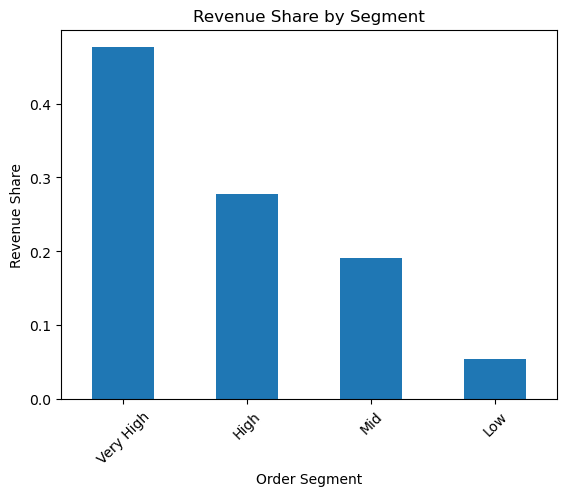

In [67]:
behavior_profile.set_index('order_segment')['revenue_share'].plot(kind='bar')

plt.title('Revenue Share by Segment')
plt.xlabel('Order Segment')
plt.ylabel('Revenue Share')

plt.xticks(rotation=45)

plt.show()

# 7.0 Strategic Interpretation & Business Recommendations

- Translate behavioral segmentation findings into actionable business strategy.
- Prioritize revenue growth opportunities based on segment contribution and timing patterns.
- Connect behavioral insights to pricing, promotions, and operational decision-making.
- Frame the analysis as a practical targeting system for revenue optimization.

## 7.1 Core Business Model Insight

- Revenue is not driven evenly across behavioral segments.
- Very High and High segments generate a disproportionate share of total revenue.
- Low-value orders contribute volume but represent a relatively small share of revenue.
- Growth opportunities are strongest when the business increases order value rather than only increasing order count.

## 7.2 Priority Segment Targeting

- Prioritize Very High and High segments as the strongest revenue drivers.
- Protect these segments during peak demand periods through:
  - faster fulfillment
  - consistent service quality
  - targeted upsell opportunities
- Avoid over-discounting top-performing segments where willingness to spend is already strong.

## 7.3 Average Order Value Expansion

- Focus revenue growth on increasing average order value across Mid and High segments.
- Use:
  - bundles
  - combo pricing
  - add-on prompts
  - premium item recommendations
- The goal is to move more orders from Mid to High and from High to Very High.

## 7.4 Peak-Hour Optimization

- Peak revenue occurs during evening hours.
- Concentrate operational efficiency during the strongest time windows:
  - staffing
  - prep readiness
  - order throughput
- Peak periods provide the highest leverage for both service quality and upsell conversion.

## 7.5 Weekend Revenue Maximization

- Revenue concentration increases toward the end of the week.
- Friday through Sunday should be treated as premium operating windows.
- Align:
  - staffing levels
  - marketing pushes
  - promotional bundles
  - inventory preparation
with weekend demand intensity.

## 7.6 Low-Value Segment Strategy

- Low-value orders contribute meaningful transaction volume but limited revenue.
- This segment should not be the primary revenue focus.
- Use low-value orders strategically for:
  - traffic generation
  - entry-level offers
  - weekday demand support
- Avoid relying on this segment alone for growth.

## 7.7 Discount Strategy Guidance

- Discounts should be used selectively rather than broadly.
- The strongest use cases for discounts are:
  - stimulating weekday demand
  - lifting lower-value orders into higher-value baskets
  - promoting targeted bundles
- Broad discounting risks reducing margin without materially improving high-value demand.

## 7.8 Strategic Recommendation Summary

- Protect and maximize Very High and High segments during peak windows.
- Increase average order value through bundles, add-ons, and premium upsells.
- Use weekday promotions to stimulate lower-demand periods.
- Treat weekends and dinner hours as the core revenue engine.
- Focus on basket expansion, not just transaction growth.

## 7.9 Executive Summary

- Behavioral segmentation shows that revenue is disproportionately driven by higher-value orders.
- The strongest growth opportunities come from increasing average order value and optimizing performance during peak demand windows.
- Time-based demand patterns indicate that dinner hours and weekends are the most important operating periods.
- The business should focus on segment-aware pricing, promotions, and operational planning to maximize revenue.